# Comparing null cutoff methods for co-occurrence network construction

This notebook tests 4 different methods for choosing significance cutoffs when building co-occurrence networks:

1. **`default`** – simulate a null community (no interactions) and use its correlation distribution
2. **`perm_100_all`** – permute the entire abundance matrix (shuffle all values), repeat 100×, use CI of correlation distribution
3. **`perm_100_within`** – shuffle within each species independently, repeat 100×, use CI of correlation distribution
4. **`pseudoP_1000`** – pairwise permutation pseudo-P: for each species pair independently shuffle one column 1000× and get a per-pair CI

For each method we compare:
- The cutoff values found
- Total number of edges (positive and negative)
- Which edges overlap between methods (Venn diagrams)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from importlib import reload
import networkx as nx
from itertools import combinations
from matplotlib_venn import venn2, venn3

import metaCommunityMx
import community_sim
import run_cooccurrence
reload(metaCommunityMx)
reload(community_sim)
reload(run_cooccurrence)

<module 'run_cooccurrence' from '/Users/fionacallahan/Documents/Nielsen_lab/TheoryCoOccur/run_cooccurrence.py'>

## 1. Parameters and matrix generation

In [2]:
# --- same parameters as run_interactDetection.ipynb ---
interactFactor = 1/5
nSpec = 100
pPositive = 0.5
pInteract = 0.05
nModules = 10

matchingParms = metaCommunityMx.hubMxMatching(nSpec, nModules, pInteractRandom=pInteract)
pWithinMod      = matchingParms['pWithinMod']
pBetweenMod     = matchingParms['pBetweenMod']
pWithinModHub   = matchingParms['pWithinModHub']
pBetweenModHub  = matchingParms['pBetweenModHub']
pHub            = matchingParms['pHub']

alpha        = 0.001
interactStren = alpha * interactFactor
samplesize   = int(0.5 * nSpec)  
numtrials    = 500
b = np.ones(nSpec) - np.random.uniform(low=0, high=0.1, size=(nSpec))

randMx = metaCommunityMx.getRandomMatrix(
    maxInteractionStrength=interactStren, pPositive=pPositive,
    pInteract=pInteract, nSpecies=nSpec, pBidirectional=0)

modMx = metaCommunityMx.generateModularMatrix(
    maxInteractionStrength=interactStren, pPositive=pPositive,
    nSpecies=nSpec, pWithinMod=pWithinMod, pBetweenMod=pBetweenMod, nModules=nModules)

hubMx = metaCommunityMx.generateHubMatrix(
    maxInteractionStrength=interactStren, pPositive=pPositive,
    nSpecies=nSpec, pWithinMod=pWithinModHub, pBetweenMod=pBetweenModHub,
    nModules=nModules, pHub=pHub)

print(f"nSpec={nSpec}, samplesize={samplesize}, numtrials={numtrials}")
print(f"Modular: pWithinMod={pWithinMod:.3f}, pBetweenMod={pBetweenMod:.4f}")
print(f"Hub:     pHub={pHub:.3f}, pWithinModHub={pWithinModHub:.4f}")

nSpec=100, samplesize=50, numtrials=500
Modular: pWithinMod=0.550, pBetweenMod=0.0000
Hub:     pHub=1.000, pWithinModHub=0.0413


## 2. Simulate co-occurrence once per matrix type

In [3]:
print("Simulating random matrix...")
rand_res  = community_sim.simulate_coOccurrence(samplesize, numtrials, a=randMx, b=b, alpha=alpha, tmax=100, y0=None)
rand_coAbd = np.round(rand_res[0], 0)
pearson_rand = np.corrcoef(rand_coAbd, rowvar=False)

print("Simulating modular matrix...")
mod_res   = community_sim.simulate_coOccurrence(samplesize, numtrials, a=modMx, b=b, alpha=alpha, tmax=100, y0=None)
mod_coAbd  = np.round(mod_res[0], 0)
pearson_mod  = np.corrcoef(mod_coAbd, rowvar=False)

print("Simulating hub matrix...")
hub_res   = community_sim.simulate_coOccurrence(samplesize, numtrials, a=hubMx, b=b, alpha=alpha, tmax=100, y0=None)
hub_coAbd  = np.round(hub_res[0], 0)
pearson_hub  = np.corrcoef(hub_coAbd, rowvar=False)

print(f"\ncoAbd shape: {rand_coAbd.shape}  (trials x sampled species)")

Simulating random matrix...
Simulating modular matrix...
Simulating hub matrix...

coAbd shape: (500, 100)  (trials x sampled species)


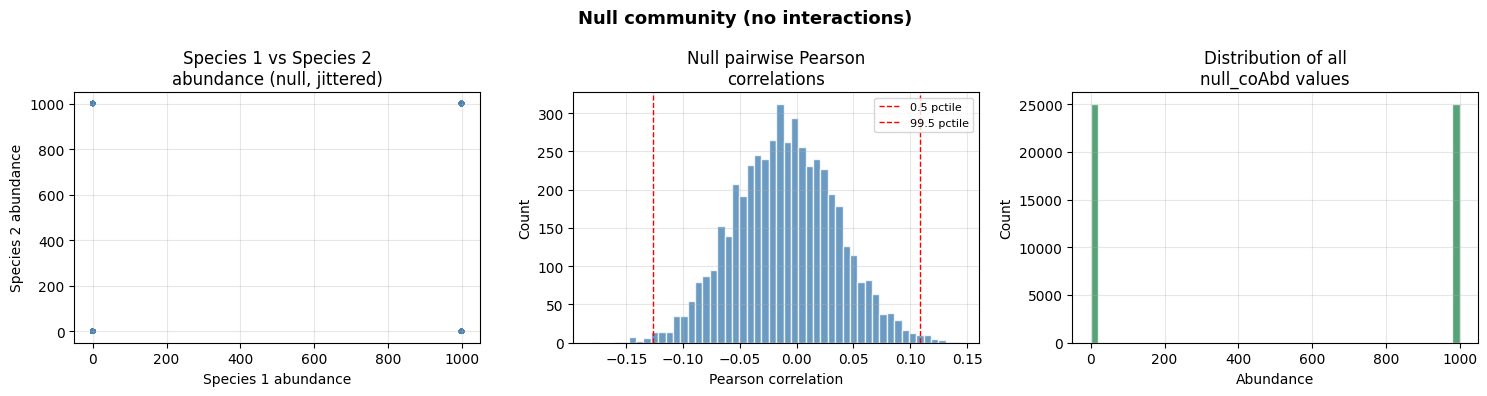

In [4]:
nullMx = np.zeros(shape=(nSpec, nSpec))
null_res  = community_sim.simulate_coOccurrence(samplesize, numtrials, a=nullMx, b=b, alpha=alpha, tmax=100, y0=None)
null_coAbd = np.round(null_res[0], 0)
pearson_null = np.corrcoef(null_coAbd, rowvar=False)

import pickle, os
os.makedirs('figure_data', exist_ok=True)
with open('figure_data/tnct_null_exploration.pkl', 'wb') as f:
    pickle.dump({'null_coAbd': null_coAbd, 'pearson_null': pearson_null, 'nSpec': nSpec}, f)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# plot abundance of species 1 versus abundance of species 2
ax = axes[0]
ax.scatter(null_coAbd[:, 0], null_coAbd[:, 1],
           alpha=0.4, s=15, color='steelblue', edgecolors='none')
ax.set_xlabel('Species 1 abundance')
ax.set_ylabel('Species 2 abundance')
ax.set_title('Species 1 vs Species 2\nabundance (null, jittered)')
ax.grid(alpha=0.3)

# plot a histogram of the pearson_null values
ax = axes[1]
upper_tri = pearson_null[np.triu_indices(nSpec, k=1)]
ax.hist(upper_tri, bins=50, color='steelblue', alpha=0.8, edgecolor='white')
ax.axvline(np.quantile(upper_tri, 0.01 / 2),  color='red', linestyle='--', linewidth=1, label='0.5 pctile')
ax.axvline(np.quantile(upper_tri, 1 - (0.01 / 2)), color='red', linestyle='--', linewidth=1, label='99.5 pctile')
ax.set_xlabel('Pearson correlation')
ax.set_ylabel('Count')
ax.set_title('Null pairwise Pearson\ncorrelations')
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

# plot a histogram of all of the values in null_coAbd
ax = axes[2]
ax.hist(null_coAbd.flatten(), bins=50, color='seagreen', alpha=0.8, edgecolor='white')
ax.set_xlabel('Abundance')
ax.set_ylabel('Count')
ax.set_title('Distribution of all\nnull_coAbd values')
ax.grid(alpha=0.3)

plt.suptitle('Null community (no interactions)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

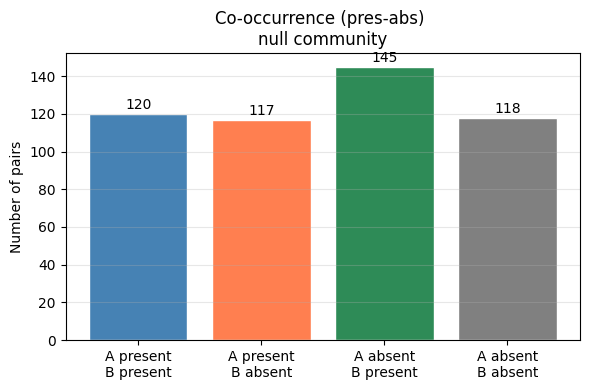

In [5]:
# plot a bar plot with 4 bars
# with one where species A is present and B present; A present B absent; B present A absent; and both absent
A = null_coAbd[:, 0] > 0
B = null_coAbd[:, 1] > 0

counts = {
    'A present\nB present': np.sum( A &  B),
    'A present\nB absent':  np.sum( A & ~B),
    'A absent\nB present':  np.sum(~A &  B),
    'A absent\nB absent':   np.sum(~A & ~B),
}

import pickle, os
os.makedirs('figure_data', exist_ok=True)
with open('figure_data/tnct_presabs.pkl', 'wb') as f:
    pickle.dump({'null_coAbd': null_coAbd}, f)

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(counts.keys(), counts.values(), color=['steelblue', 'coral', 'seagreen', 'gray'], edgecolor='white')
ax.set_ylabel('Number of pairs')
ax.set_title('Co-occurrence (pres-abs) \nnull community')
for i, (label, count) in enumerate(counts.items()):
    ax.text(i, count + 1, str(count), ha='center', va='bottom', fontsize=10)
ax.grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

In [6]:
# --- Method 2: permute all ---
print(f"perm_100_all ...")
lower2, upper2 = run_cooccurrence.get_null_cutoff_permute(
    cooc_mx=null_coAbd, pval_alpha=0.01, shuffle_all=True, n_shuffle=10)
net = (np.greater(pearson_null, upper2).astype(int)
        - np.less(pearson_null, lower2).astype(int))
np.fill_diagonal(net, 0)

# --- Method 3: permute within species ---
print(f"perm_100_within ...")
lower3, upper3 = run_cooccurrence.get_null_cutoff_permute(
    cooc_mx=null_coAbd, pval_alpha=0.01, shuffle_all=False, n_shuffle=10)
net = (np.greater(pearson_null, upper3).astype(int)
        - np.less(pearson_null, lower3).astype(int))
np.fill_diagonal(net, 0)

# --- Method 4: pairwise pseudoP ---
print(f"pseudoP_1000 ...")
lower_cutoff_mx, upper_cutoff_mx, net = run_cooccurrence.get_network_pairwise_pseudoP(
    cooc_mx=null_coAbd, pval_alpha=0.01, n_shuffle=100)

print("Method 2: permute all")
print(lower2, upper2)

print("Method 3: permute within species")
print(lower3, upper3)

print("pseudoP_100")
print(np.mean(lower_cutoff_mx))
print(np.mean(upper_cutoff_mx))

perm_100_all ...
perm_100_within ...
pseudoP_1000 ...
Method 2: permute all
-0.11386846927525902 0.11538390836000212
Method 3: permute within species
-0.1147069525024047 0.11547448165468746
pseudoP_100
-0.10296364058043325
0.10320173284077815


## 3. Apply all four null cutoff methods

| Method | Function | Key params |
|---|---|---|
| `default` | `get_null_cutoff` | fresh null simulation |
| `perm_100_all` | `get_null_cutoff_permute` | `shuffle_all=True`, `n_shuffle=100` |
| `perm_100_within` | `get_null_cutoff_permute` | `shuffle_all=False`, `n_shuffle=100` |
| `pseudoP_1000` | `get_network_pairwise_pseudoP` | `n_shuffle=1000` (per-pair CI) |

`pseudoP_1000` runs ~1.2M correlation calculations and may take ~1–2 min.

In [7]:
pval_alpha       = 0.01
n_perm_cutoff    = 100
n_pseudoP        = 1000
method_names     = ['default', 'perm_100_all', 'perm_100_within', 'pseudoP_1000']
method_labels    = {
    'default':         'Default\n(null sim)',
    'perm_100_all':    'Perm-all\nn=100',
    'perm_100_within': 'Perm-within\nn=100',
    'pseudoP_1000':    'PseudoP\nn=1000',
}

def apply_null_methods(coAbd, pearson_corr, label=''):
    """Apply all four null methods to the same coAbd (coabundance data per species) and return per-method network matrices."""
    results = {}

    # --- Method 1: default simulation-based null ---
    print(f"  [{label}] default ...")
    lower, upper = run_cooccurrence.get_null_cutoff(
        nSpec=nSpec, alpha=alpha, spsamplesize=samplesize,
        numtrials=numtrials, b=b, pval_alpha=pval_alpha, tmax=100)
    net = (np.greater(pearson_corr, upper).astype(int)
           - np.less(pearson_corr, lower).astype(int))
    np.fill_diagonal(net, 0)
    results['default'] = {'network': net, 'lower': lower, 'upper': upper}

    # --- Method 2: permute all ---
    print(f"  [{label}] perm_100_all ...")
    lower, upper = run_cooccurrence.get_null_cutoff_permute(
        cooc_mx=coAbd, pval_alpha=pval_alpha, shuffle_all=True, n_shuffle=n_perm_cutoff)
    net = (np.greater(pearson_corr, upper).astype(int)
           - np.less(pearson_corr, lower).astype(int))
    np.fill_diagonal(net, 0)
    results['perm_100_all'] = {'network': net, 'lower': lower, 'upper': upper}

    # --- Method 3: permute within species ---
    print(f"  [{label}] perm_100_within ...")
    lower, upper = run_cooccurrence.get_null_cutoff_permute(
        cooc_mx=coAbd, pval_alpha=pval_alpha, shuffle_all=False, n_shuffle=n_perm_cutoff)
    net = (np.greater(pearson_corr, upper).astype(int)
           - np.less(pearson_corr, lower).astype(int))
    np.fill_diagonal(net, 0)
    results['perm_100_within'] = {'network': net, 'lower': lower, 'upper': upper}

    # --- Method 4: pairwise pseudoP ---
    print(f"  [{label}] pseudoP_1000 (slow) ...")
    _, _, net = run_cooccurrence.get_network_pairwise_pseudoP(
        cooc_mx=coAbd, pval_alpha=pval_alpha, n_shuffle=n_pseudoP)
    results['pseudoP_1000'] = {'network': net, 'lower': None, 'upper': None}

    return results


rand_results = apply_null_methods(rand_coAbd, pearson_rand, label='Random')
mod_results  = apply_null_methods(mod_coAbd,  pearson_mod,  label='Modular')
hub_results  = apply_null_methods(hub_coAbd,  pearson_hub,  label='Hub')

all_results   = [rand_results, mod_results, hub_results]
matrix_names  = ['Random', 'Modular', 'Hub']
print("\nDone.")

  [Random] default ...
  [Random] perm_100_all ...
  [Random] perm_100_within ...
  [Random] pseudoP_1000 (slow) ...
  [Modular] default ...
  [Modular] perm_100_all ...
  [Modular] perm_100_within ...
  [Modular] pseudoP_1000 (slow) ...
  [Hub] default ...
  [Hub] perm_100_all ...
  [Hub] perm_100_within ...
  [Hub] pseudoP_1000 (slow) ...

Done.


In [8]:
# Print cutoff summary table
print(f"{'Method':<22} {'Matrix':<10} {'Lower':>9} {'Upper':>9}")
print("-" * 56)
for results, mname in zip(all_results, matrix_names):
    for method in method_names:
        lo = results[method]['lower']
        hi = results[method]['upper']
        lo_s = f"{lo:.4f}" if lo is not None else "per-pair"
        hi_s = f"{hi:.4f}" if hi is not None else "per-pair"
        print(f"{method:<22} {mname:<10} {lo_s:>9} {hi_s:>9}")
    print()

Method                 Matrix         Lower     Upper
--------------------------------------------------------
default                Random       -0.1253    0.1040
perm_100_all           Random       -0.1149    0.1149
perm_100_within        Random       -0.1148    0.1144
pseudoP_1000           Random      per-pair  per-pair

default                Modular      -0.1286    0.1010
perm_100_all           Modular      -0.1148    0.1146
perm_100_within        Modular      -0.1144    0.1149
pseudoP_1000           Modular     per-pair  per-pair

default                Hub          -0.1277    0.1033
perm_100_all           Hub          -0.1144    0.1150
perm_100_within        Hub          -0.1148    0.1149
pseudoP_1000           Hub         per-pair  per-pair



## 4. Edge count comparison

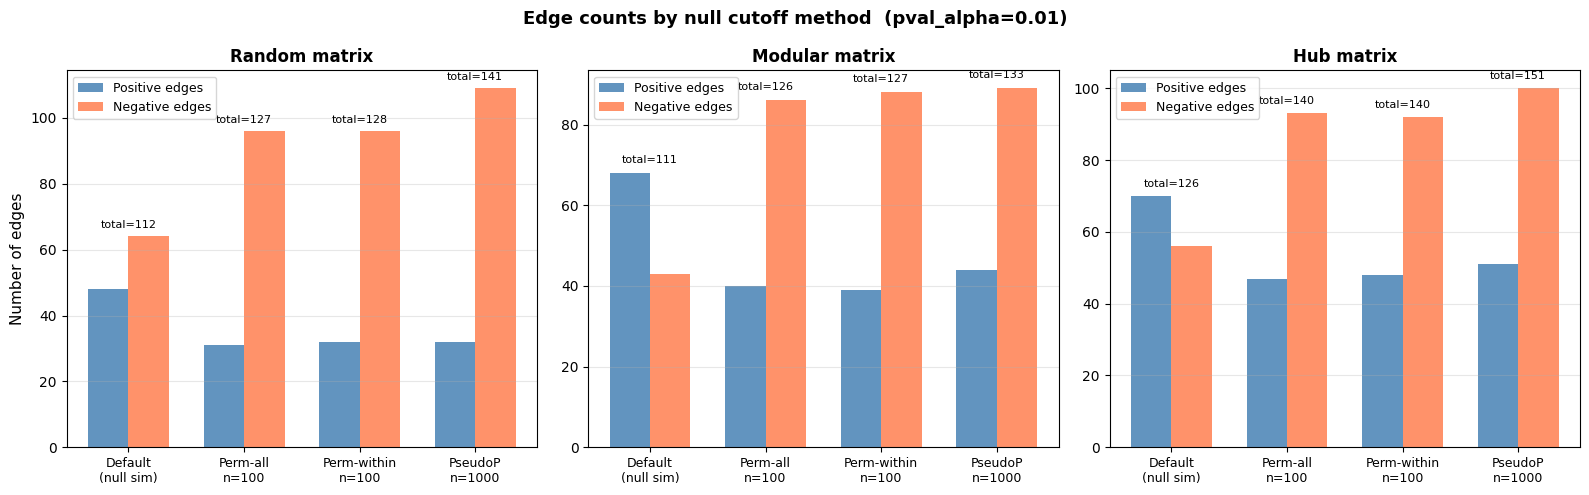

In [9]:
def count_edges(net):
    triu = np.triu(net, k=1)
    return int(np.sum(triu > 0)), int(np.sum(triu < 0))

import pickle, os
os.makedirs('figure_data', exist_ok=True)
_edge_count_data = {}
for _mname, _results in zip(matrix_names, all_results):
    _edge_count_data[_mname] = {}
    for _m in method_names:
        _pos, _neg = count_edges(_results[_m]['network'])
        _edge_count_data[_mname][_m] = {'pos': _pos, 'neg': _neg}
with open('figure_data/tnct_edge_counts.pkl', 'wb') as f:
    pickle.dump({'edge_count_data': _edge_count_data, 'method_names': method_names, 'method_labels': method_labels, 'matrix_names': matrix_names}, f)

x = np.arange(len(method_names))
w = 0.35
colors_pos = ['steelblue', 'seagreen', 'darkorange', 'mediumpurple']
colors_neg = ['lightsteelblue', 'lightgreen', 'peachpuff', 'thistle']

fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=False)

for ax, results, mname in zip(axes, all_results, matrix_names):
    pos_counts, neg_counts = zip(*[count_edges(results[m]['network']) for m in method_names])
    totals = [p + n for p, n in zip(pos_counts, neg_counts)]

    bars_pos = ax.bar(x - w/2, pos_counts, w, label='Positive edges', color='steelblue', alpha=0.85)
    bars_neg = ax.bar(x + w/2, neg_counts, w, label='Negative edges', color='coral',     alpha=0.85)

    # annotate with totals
    for i, tot in enumerate(totals):
        ax.text(i, max(pos_counts[i], neg_counts[i]) + 2, f'total={tot}',
                ha='center', va='bottom', fontsize=8)

    ax.set_xticks(x)
    ax.set_xticklabels([method_labels[m] for m in method_names], fontsize=9)
    ax.set_title(f'{mname} matrix', fontsize=12, fontweight='bold')
    if ax is axes[0]:
        ax.set_ylabel('Number of edges', fontsize=11)
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3, axis='y')

plt.suptitle('Edge counts by null cutoff method  (pval_alpha=0.01)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 5. Venn diagrams of edge overlap

For each matrix type we show:
- **3-way Venn** for the three global-cutoff methods (`default`, `perm_100_all`, `perm_100_within`)
- **2-way Venns** comparing `pseudoP_1000` against each of the other three

Edges are undirected pairs (i, j) with i < j, regardless of sign.

In [10]:
def to_edge_set(net):
    rows, cols = np.where(np.triu(net != 0, k=1))
    return set(zip(rows.tolist(), cols.tolist()))

def to_pos_neg_sets(net):
    triu = np.triu(net, k=1)
    rp, cp = np.where(triu > 0)
    rn, cn = np.where(triu < 0)
    return set(zip(rp.tolist(), cp.tolist())), set(zip(rn.tolist(), cn.tolist()))

# Build edge sets for every method × matrix combination
edge_sets = {
    mname: {m: to_edge_set(results[m]['network']) for m in method_names}
    for mname, results in zip(matrix_names, all_results)
}

# Quick size check
print(f"{'Matrix':<10} {'Method':<22} {'Edges':>6}")
print("-" * 42)
for mname in matrix_names:
    for m in method_names:
        print(f"{mname:<10} {m:<22} {len(edge_sets[mname][m]):>6}")
    print()

Matrix     Method                  Edges
------------------------------------------
Random     default                   112
Random     perm_100_all              127
Random     perm_100_within           128
Random     pseudoP_1000              141

Modular    default                   111
Modular    perm_100_all              126
Modular    perm_100_within           127
Modular    pseudoP_1000              133

Hub        default                   126
Hub        perm_100_all              140
Hub        perm_100_within           140
Hub        pseudoP_1000              151



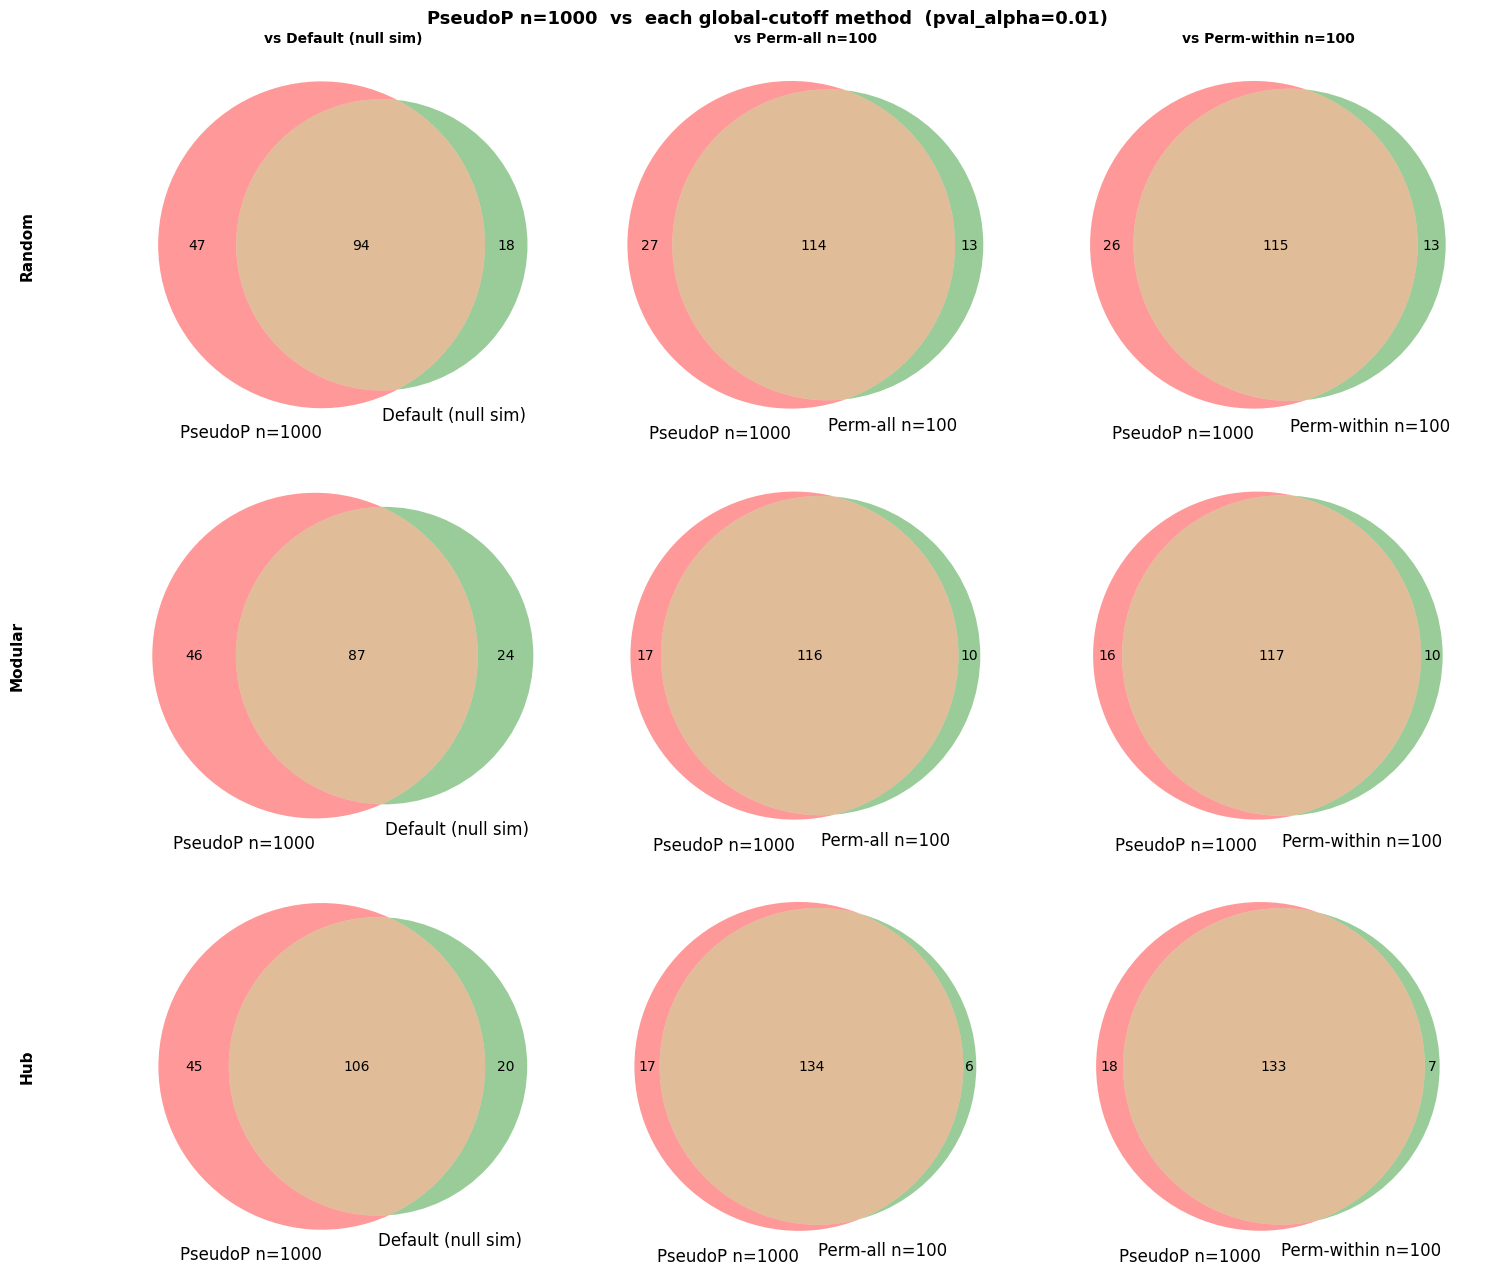

In [11]:
# --- 2-way Venns: pseudoP_1000 vs each of the other three (3 rows × 3 cols) ---

compare_to = ['default', 'perm_100_all', 'perm_100_within']

import pickle, os
os.makedirs('figure_data', exist_ok=True)
# Convert sets of tuples to lists for pickling reliability
_edge_sets_serializable = {
    mname: {m: sorted(list(s)) for m, s in method_sets.items()}
    for mname, method_sets in edge_sets.items()
}
with open('figure_data/tnct_venn.pkl', 'wb') as f:
    pickle.dump({'edge_sets': _edge_sets_serializable, 'method_names': method_names, 'method_labels': method_labels, 'matrix_names': matrix_names}, f)

fig, axes = plt.subplots(3, 3, figsize=(15, 13))
for row, mname in enumerate(matrix_names):
    for col, other in enumerate(compare_to):
        ax = axes[row, col]
        s1 = edge_sets[mname]['pseudoP_1000']
        s2 = edge_sets[mname][other]
        venn2([s1, s2],
                set_labels=('PseudoP n=1000', method_labels[other].replace('\n', ' ')),
                ax=ax)
        if row == 0:
            ax.set_title(f'vs {method_labels[other].replace(chr(10), " ")}',
                            fontsize=10, fontweight='bold')
        if col == 0:
            ax.text(-0.25, 0.5, mname, transform=ax.transAxes,
                    fontsize=11, fontweight='bold', va='center', rotation=90)

plt.suptitle('PseudoP n=1000  vs  each global-cutoff method  (pval_alpha=0.01)',
                fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

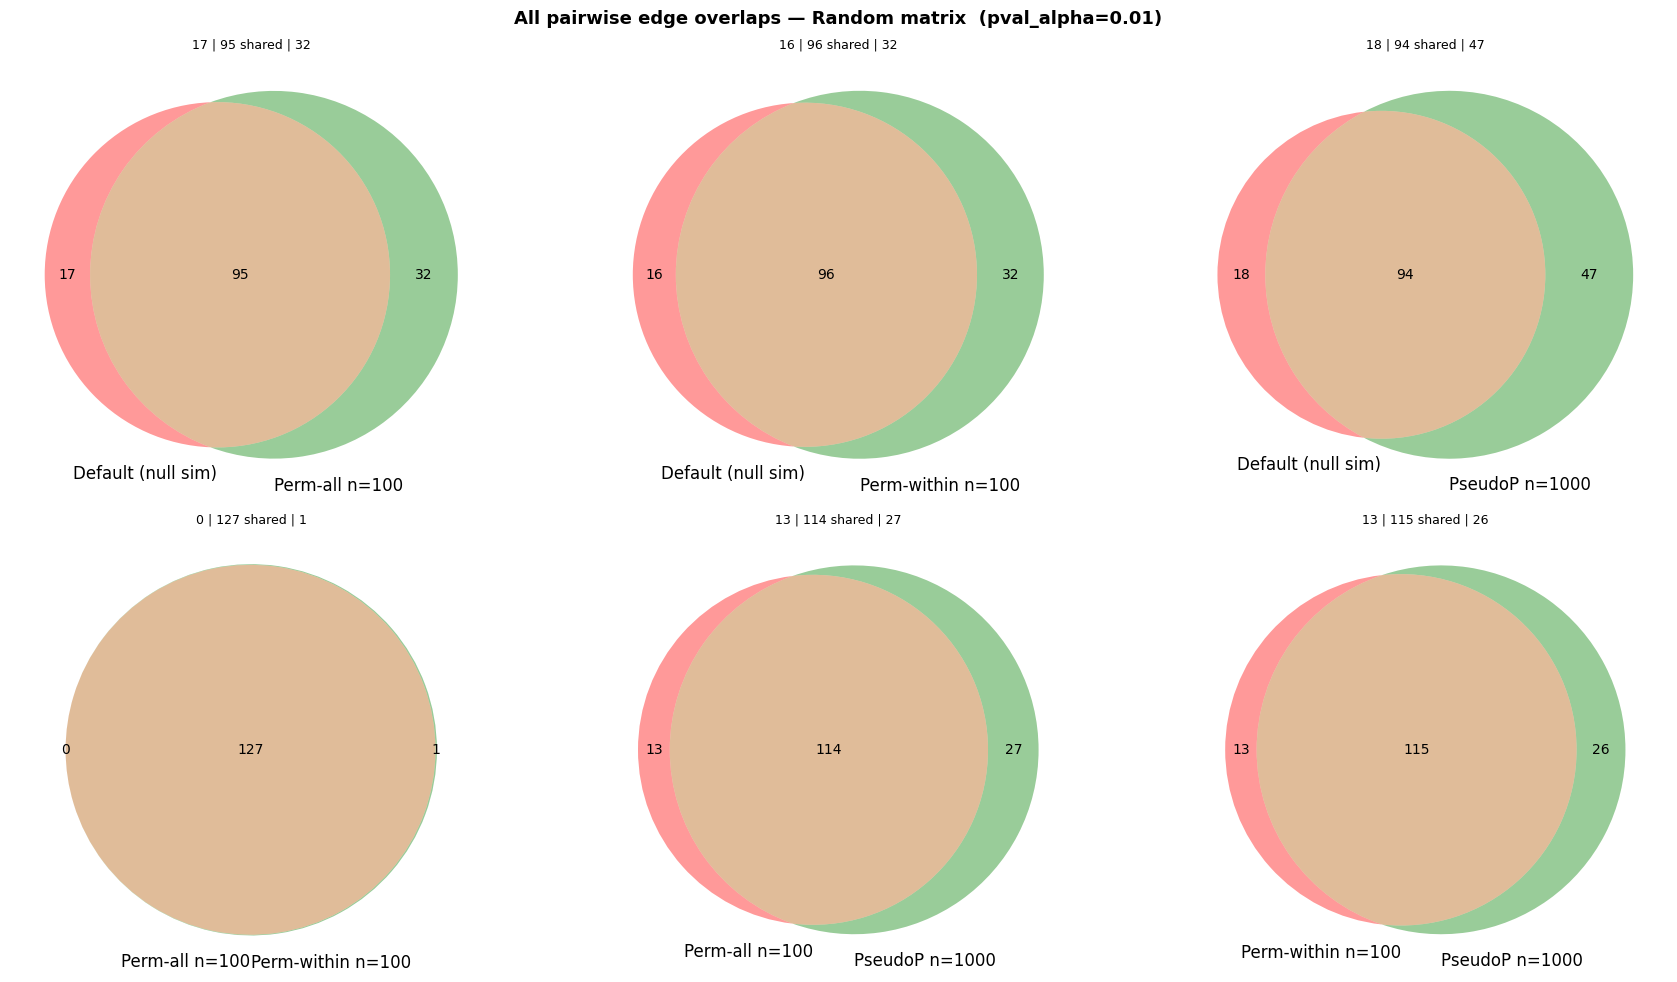

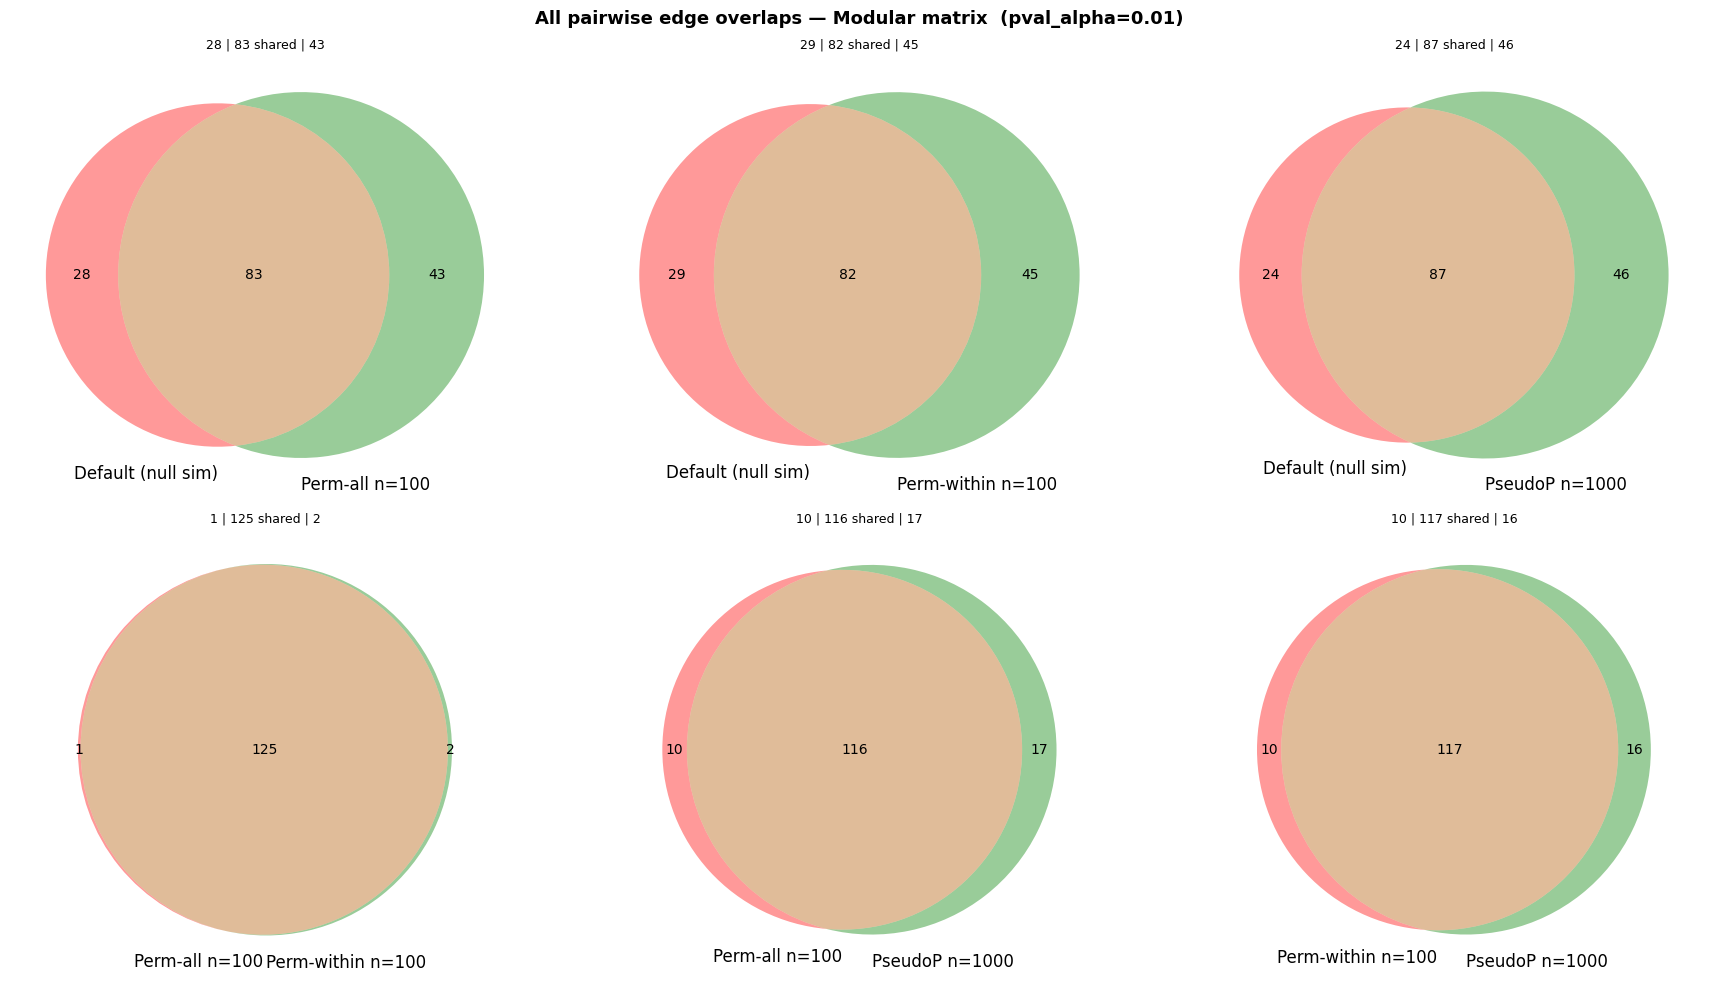

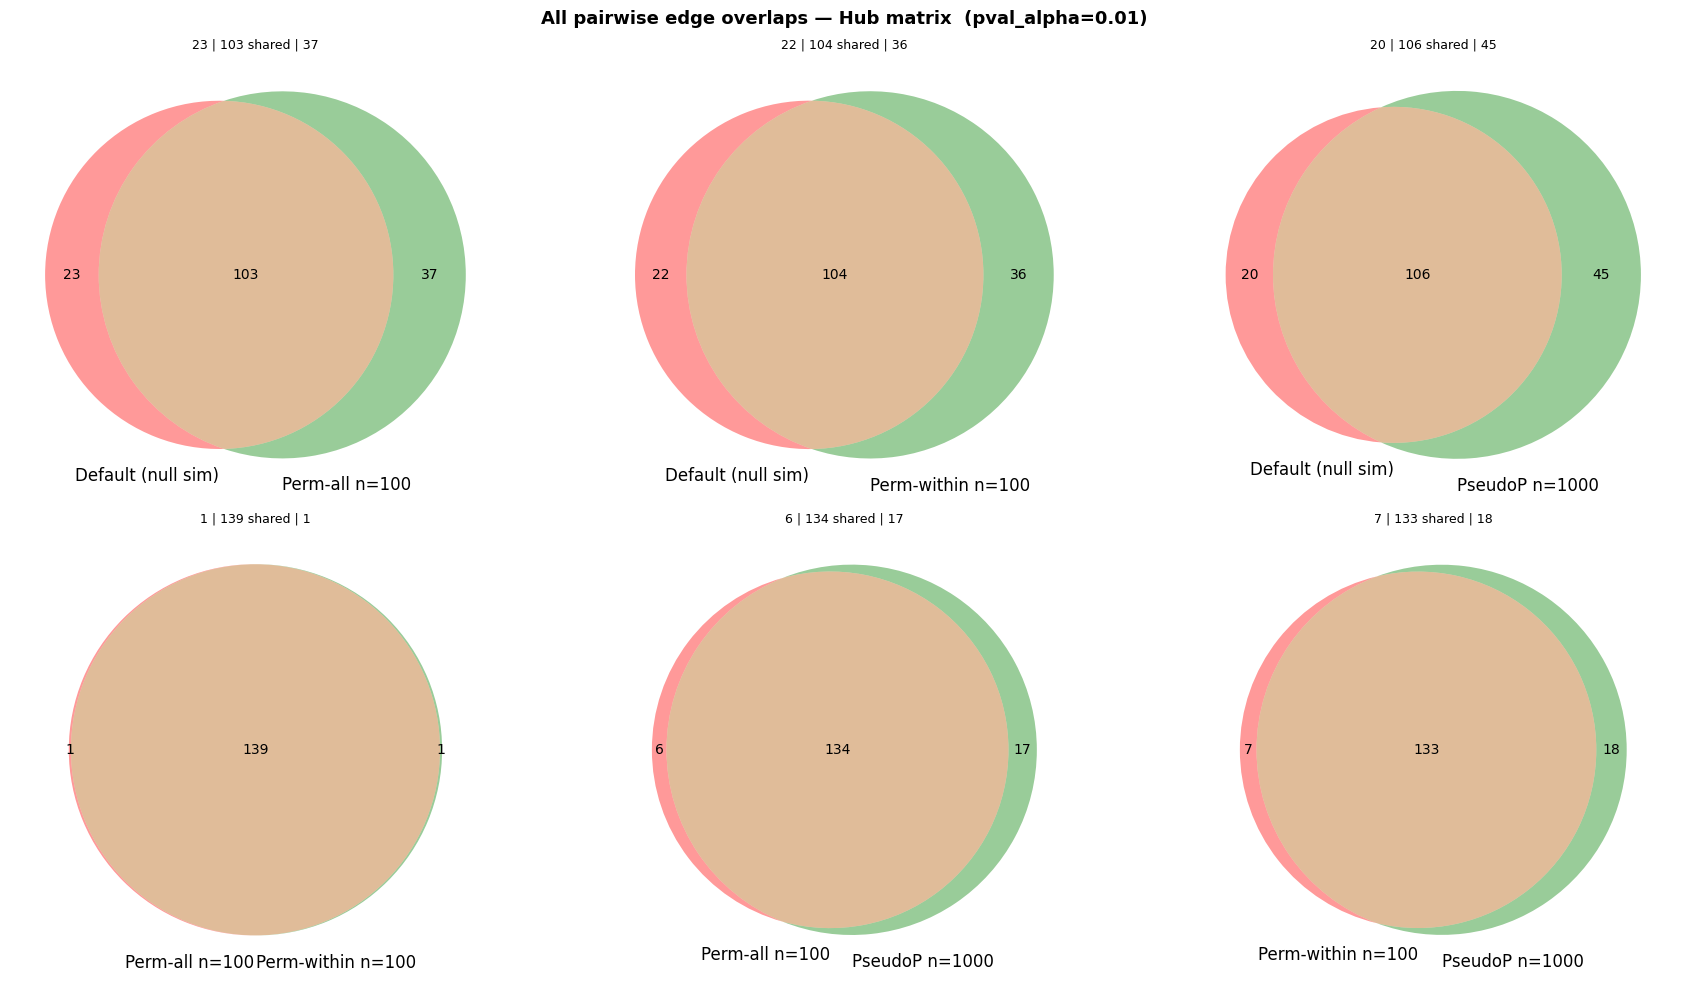

In [12]:
# Figure data already saved in tnct_venn.pkl (cell c5d6e7f8)

# --- All 6 pairwise Venns per matrix type (2 rows × 3 cols per matrix = 3 figures) ---

all_pairs = list(combinations(method_names, 2))

for mname in matrix_names:
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    axes_flat = axes.flatten()
    for ax, (m1, m2) in zip(axes_flat, all_pairs):
        s1 = edge_sets[mname][m1]
        s2 = edge_sets[mname][m2]
        venn2([s1, s2],
                set_labels=(method_labels[m1].replace('\n', ' '),
                            method_labels[m2].replace('\n', ' ')),
                ax=ax)
        n_only1  = len(s1 - s2)
        n_shared = len(s1 & s2)
        n_only2  = len(s2 - s1)
        ax.set_title(f'{n_only1} | {n_shared} shared | {n_only2}', fontsize=9)

    plt.suptitle(f'All pairwise edge overlaps — {mname} matrix  (pval_alpha=0.01)',
                    fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()